# **Deliverable 2: Data Collection & Cleaning**

In [56]:
# import modules for EDA
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
# importing dataset
neo_coffee_shop = pd.read_csv('/content/Neo_Coffee.csv')

In [58]:
# creating a copy of the dataset
neo_coffee_shop1 = neo_coffee_shop.copy()

In [59]:
# loading first 5 of the dataset
neo_coffee_shop1.head(5)

,order id,order date,customer id,product id,quantity,customer name,customer email,phone number,address line 1,city,country,postcode,loyalty card,coffee type,roast type,size,unit price,price per 100g,profit
0,QEV-37451-860,2021-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970
1,QEV-37451-860,2021-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075
2,FAA-43335-268,2023-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655
3,KAC-83089-793,2023-07-15,23806-46781-OU,E-M-1,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125
4,KAC-83089-793,2023-07-15,23806-46781-OU,R-L-2.5,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491


In [60]:
# summary of the dataset
neo_coffee_shop1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order id        1000 non-null   object 
 1   order date      1000 non-null   object 
 2   customer id     1000 non-null   object 
 3   product id      1000 non-null   object 
 4   quantity        1000 non-null   int64  
 5   customer name   1000 non-null   object 
 6   customer email  794 non-null    object 
 7   phone number    865 non-null    object 
 8   address line 1  1000 non-null   object 
 9   city            1000 non-null   object 
 10  country         1000 non-null   object 
 11  postcode        1000 non-null   object 
 12  loyalty card    1000 non-null   object 
 13  coffee type     1000 non-null   object 
 14  roast type      1000 non-null   object 
 15  size            1000 non-null   float64
 16  unit price      1000 non-null   float64
 17  price per 100g  1000 non-null   fl

In [61]:
# converting data types to right formats
neo_coffee_shop1['order date'] = pd.to_datetime(neo_coffee_shop1['order date'])
num_cols = ['quantity', 'unit price', 'price per 100g','profit','size']
neo_coffee_shop1[num_cols] = neo_coffee_shop1[num_cols].apply(pd.to_numeric, errors='coerce')
neo_coffee_shop1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order id        1000 non-null   object        
 1   order date      1000 non-null   datetime64[ns]
 2   customer id     1000 non-null   object        
 3   product id      1000 non-null   object        
 4   quantity        1000 non-null   int64         
 5   customer name   1000 non-null   object        
 6   customer email  794 non-null    object        
 7   phone number    865 non-null    object        
 8   address line 1  1000 non-null   object        
 9   city            1000 non-null   object        
 10  country         1000 non-null   object        
 11  postcode        1000 non-null   object        
 12  loyalty card    1000 non-null   object        
 13  coffee type     1000 non-null   object        
 14  roast type      1000 non-null   object        
 15  size 

In [62]:
# removing duplicates
neo_coffee_shop1 = neo_coffee_shop1.drop_duplicates()
neo_coffee_shop1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order id        1000 non-null   object        
 1   order date      1000 non-null   datetime64[ns]
 2   customer id     1000 non-null   object        
 3   product id      1000 non-null   object        
 4   quantity        1000 non-null   int64         
 5   customer name   1000 non-null   object        
 6   customer email  794 non-null    object        
 7   phone number    865 non-null    object        
 8   address line 1  1000 non-null   object        
 9   city            1000 non-null   object        
 10  country         1000 non-null   object        
 11  postcode        1000 non-null   object        
 12  loyalty card    1000 non-null   object        
 13  coffee type     1000 non-null   object        
 14  roast type      1000 non-null   object        
 15  size 

In [63]:
# filtering unrealistic datas
neo_c0ffee_shop1 = neo_coffee_shop1[(neo_coffee_shop1['quantity']> 0) & (neo_coffee_shop1['price per 100g'] > 0) &
                                  (neo_coffee_shop1['profit'] > 0) & (neo_coffee_shop1['size'] > 0)]
neo_coffee_shop1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order id        1000 non-null   object        
 1   order date      1000 non-null   datetime64[ns]
 2   customer id     1000 non-null   object        
 3   product id      1000 non-null   object        
 4   quantity        1000 non-null   int64         
 5   customer name   1000 non-null   object        
 6   customer email  794 non-null    object        
 7   phone number    865 non-null    object        
 8   address line 1  1000 non-null   object        
 9   city            1000 non-null   object        
 10  country         1000 non-null   object        
 11  postcode        1000 non-null   object        
 12  loyalty card    1000 non-null   object        
 13  coffee type     1000 non-null   object        
 14  roast type      1000 non-null   object        
 15  size 

In [64]:
# identifying missing data
neo_coffee_shop1.isnull().sum()

,0
order id,0
order date,0
customer id,0
product id,0
quantity,0
customer name,0
customer email,206
phone number,135
address line 1,0
city,0


In [65]:
# filling in missing data for CUSTOMER EMAIL & PHONE NUMBERS  with UNKNOWN
# since this are identifiers and not variables
neo_coffee_shop1['customer email'] = neo_coffee_shop1['customer email'].fillna('Unknown')
neo_coffee_shop1['phone number'] = neo_coffee_shop1['phone number'].fillna('Unknown')

In [66]:
neo_coffee_shop1.isnull().sum()

,0
order id,0
order date,0
customer id,0
product id,0
quantity,0
customer name,0
customer email,0
phone number,0
address line 1,0
city,0


<Axes: xlabel='profit'>

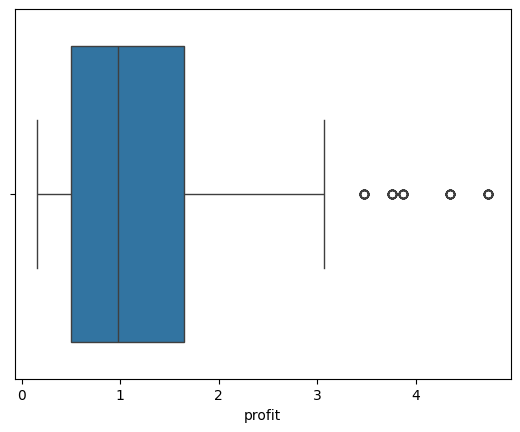

In [67]:
# detecting outliers in unit price, price per 100g, profit. they are numeric values
# using visual detection to see extreme values
sns.boxplot(x=neo_coffee_shop1['profit'])

<Axes: xlabel='price per 100g'>

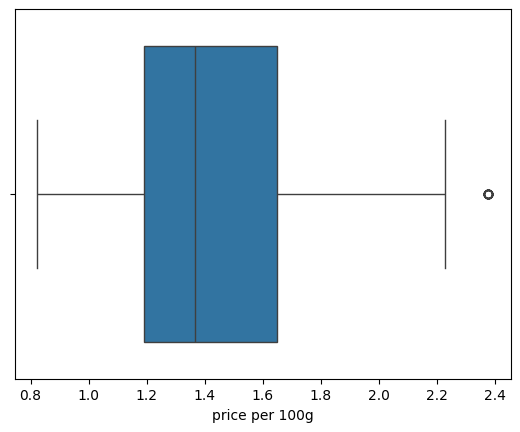

In [68]:
sns.boxplot(x=neo_coffee_shop1['price per 100g'])

<Axes: xlabel='unit price'>

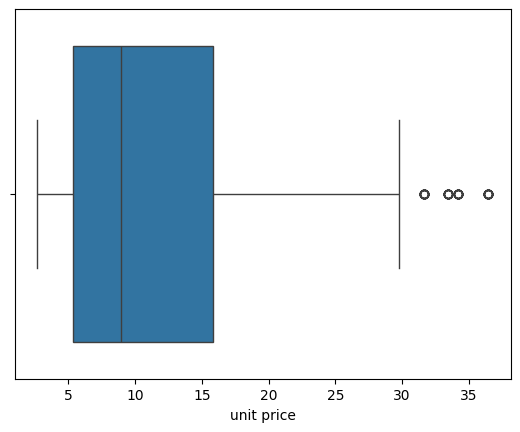

In [69]:
sns.boxplot(x=neo_coffee_shop1['unit price'])

In [70]:
# handling outliers found in unit price, price per 100g & profit
neo_coffee_shop1[['unit price', 'price per 100g', 'profit']].describe()

,unit price,price per 100g,profit
count,1000.000000,1000.000000,1000.000000
mean,12.908080,1.438336,1.301375
std,9.772455,0.365525,1.128052
min,2.685000,0.823400,0.161100
25%,5.370000,1.191400,0.505050
50%,8.950000,1.366200,0.980100
75%,15.850000,1.650000,1.649100
max,36.455000,2.377500,4.739150


In [71]:
# calculating IQR boundaries for 'unit price'
def cap_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return column.clip(lower=lower_bound, upper=upper_bound)

neo_coffee_shop1['unit price capped'] = cap_outliers(neo_coffee_shop1['unit price'])
neo_coffee_shop1 ['price per 100g capped'] = cap_outliers(neo_coffee_shop1['price per 100g'])
neo_coffee_shop1 ['profit capped'] = cap_outliers(neo_coffee_shop1['profit'])

In [72]:
neo_coffee_shop1[['unit price capped', 'price per 100g capped', 'profit capped']].describe()


,unit price capped,price per 100g capped,profit capped
count,1000.000000,1000.000000,1000.000000
mean,12.734160,1.437346,1.237792
std,9.397905,0.363022,0.971802
min,2.685000,0.823400,0.161100
25%,5.370000,1.191400,0.505050
50%,8.950000,1.366200,0.980100
75%,15.850000,1.650000,1.649100
max,31.570000,2.337900,3.365175


In [73]:
# creating another pipeline for capped data
# dropping numeric columns that was not capped from original data
neo_coffee_shopcapped = neo_coffee_shop1.copy()
neo_coffee_shopcapped = neo_coffee_shopcapped.drop(['unit price', 'price per 100g', 'profit'], axis=1)

In [74]:
neo_coffee_shopcapped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order id               1000 non-null   object        
 1   order date             1000 non-null   datetime64[ns]
 2   customer id            1000 non-null   object        
 3   product id             1000 non-null   object        
 4   quantity               1000 non-null   int64         
 5   customer name          1000 non-null   object        
 6   customer email         1000 non-null   object        
 7   phone number           1000 non-null   object        
 8   address line 1         1000 non-null   object        
 9   city                   1000 non-null   object        
 10  country                1000 non-null   object        
 11  postcode               1000 non-null   object        
 12  loyalty card           1000 non-null   object        
 13  coff

<Axes: xlabel='profit capped'>

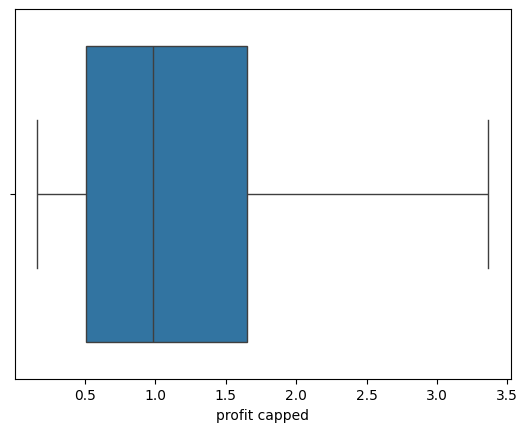

In [75]:
# visual representation of profit, pice per 100g and unit price after handling outliers
sns.boxplot(x=neo_coffee_shop1['profit capped'])

<Axes: xlabel='unit price capped'>

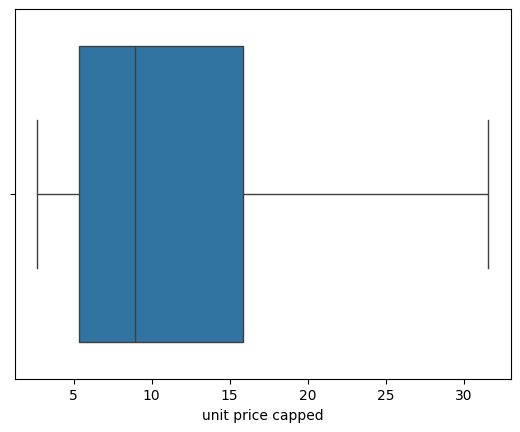

In [76]:
sns.boxplot(x=neo_coffee_shop1['unit price capped'])

<Axes: xlabel='price per 100g capped'>

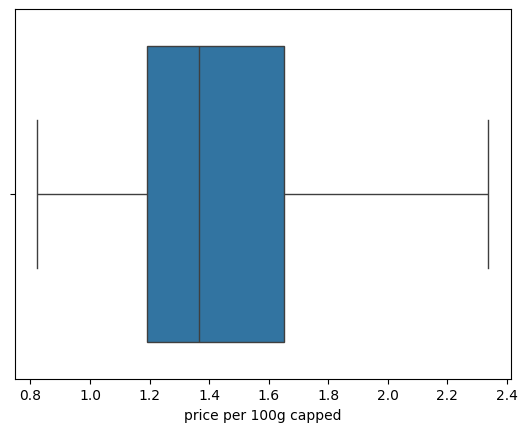

In [77]:
sns.boxplot(x=neo_coffee_shop1['price per 100g capped'])

In [78]:
# converting capped numerical columns to numpy arrays
unit_price = neo_coffee_shopcapped['unit price capped'].to_numpy()
price_per_100g = neo_coffee_shopcapped['price per 100g capped'].to_numpy()
profit = neo_coffee_shopcapped['profit capped'].to_numpy()
quantity = neo_coffee_shopcapped['quantity'].to_numpy()
size = neo_coffee_shopcapped['size'].to_numpy()



# **explanation of cleaning and imputation decisions**
The primary goal of this cleaning phase was to transform the raw dataset of 1,000 transactions into a "model-ready" state.I focused on two main areas:

1. resolving missing categorical values and stabilizing numerical variance through outlier management.
2. Handling Missing Data (Categorical Imputation)During the initial audit, missing values were identified in the Personally Identifiable Information (PII) columns.

Affected Columns: Customer Email, Phone Number.

Action Taken: Non-Destructive Constant Imputation.

Logic: All null entries were replaced with the string "Unknown".
Rationale: Since email and phone data are unique identifiers, they cannot be mathematically inferred (imputed by mean/mode). By using "Unknown" rather than deleting the rows, i preserve the transactional volume and financial integrity of the 1,000 records.

3. Outlier Management (Numerical Capping)To prevent extreme values from skewing our descriptive and inferential statistics, i addressed outliers in the core financial columns.

Affected Columns: Unit Price, Price per 100g and  Profit

Methodology: Winsorization (Capping) via the Interquartile Range (IQR) method.

Detection: i utilized Boxplots to identify values falling outside the statistical "whiskers" (defined as $Q1 - 1.5 \times IQR$ and $Q3 + 1.5 \times IQR$).

Implementation: Using NumPy’s clip function, outliers were capped at the upper and lower boundaries rather than being removed.

Rationale: In a coffee shop environment, extreme values often represent valid "bulk" or "specialty" purchases. Deleting them would result in an inaccurate total revenue figure. Capping allows us to retain the transaction in our dataset while preventing these high-leverage points from disproportionately affecting the mean and standard deviation.

4. Post-Cleaning Verification Following these operations, a secondary audit was performed:Null Count: 0 (Confirmed via np.sum(df.isnull().values)).Distribution: Boxplot analysis confirms that while the data retains its natural variance, the extreme tails have been neutralized.

# **Time Series & Trend Analysis**

In [79]:
# Calculating Gross Revenue per order
gross_revenue = quantity * unit_price
# calculating total shop revenue
total_shop_revenue = np.sum(gross_revenue)
print(f"Total Shop Revenue: ${total_shop_revenue:.2f}")

Total Shop Revenue: $44578.60


In [80]:
# neo_coffee_shopcapped DataFrame sorted by 'order date' and copied to neo_coffee_sorted.
neo_coffee_shopcapped = neo_coffee_shopcapped.sort_values(by='order date', ascending=True)
neo_coffee_sorted = neo_coffee_shopcapped.copy()


In [81]:
# calculating the daily revenue and its cumulative sum to analyze the overall revenue trend.
daily_revenue = (neo_coffee_sorted['quantity'] * neo_coffee_sorted['unit price capped']).to_numpy()
cumulative_revenue = np.cumsum(daily_revenue)


In [82]:
# calculating monthly and yearly revenue trend
neo_coffee_sorted['year'] = neo_coffee_sorted['order date'].dt.year
neo_coffee_sorted['month'] = neo_coffee_sorted['order date'].dt.month

In [83]:
monthly_revenue = neo_coffee_sorted.groupby(['year', 'month'])['unit price capped'].sum().reset_index()
yearly_revenue = neo_coffee_sorted.groupby('year')['unit price capped'].sum().reset_index()

print(monthly_revenue)
print(yearly_revenue)

    year  month  unit price capped
0   2021      1            218.880
1   2021      2            324.085
2   2021      3            291.130
3   2021      4            388.160
4   2021      5            118.505
5   2021      6            311.260
6   2021      7            269.120
7   2021      8            202.265
8   2021      9            368.030
9   2021     10            304.730
10  2021     11            247.890
11  2021     12            307.290
12  2022      1            238.895
13  2022      2            455.955
14  2022      3            253.620
15  2022      4            215.340
16  2022      5            281.640
17  2022      6            399.860
18  2022      7            391.220
19  2022      8            117.060
20  2022      9            188.045
21  2022     10            441.400
22  2022     11            303.505
23  2022     12            223.520
24  2023      1            279.370
25  2023      2            247.450
26  2023      3            400.925
27  2023      4     

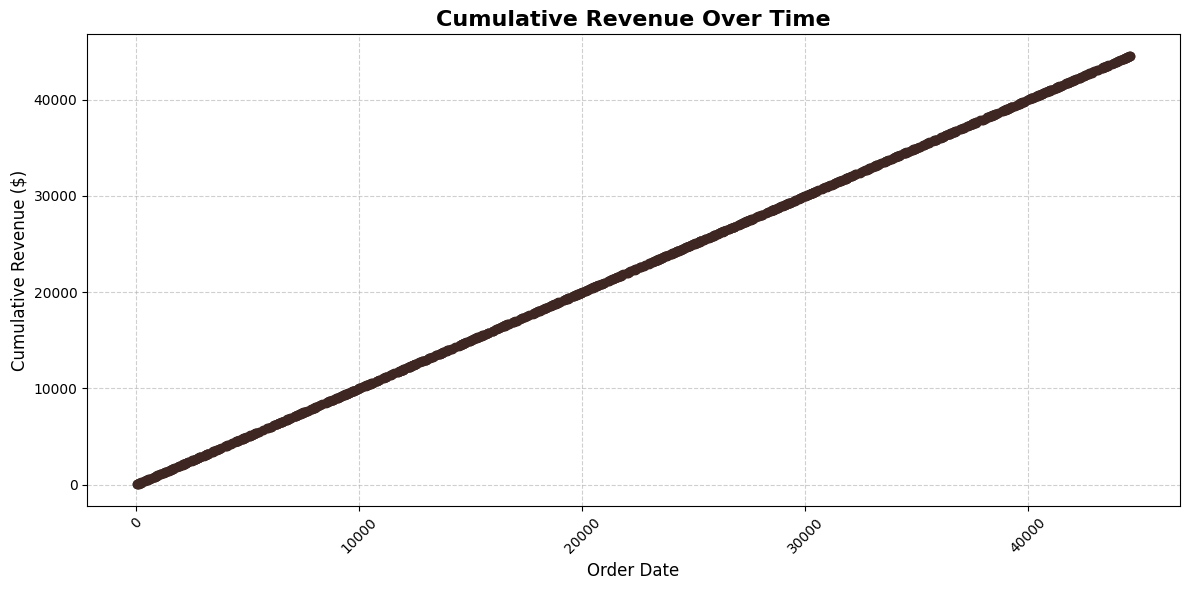

Cumulative revenue trend plotted.


In [84]:
# plotting the cumulative revenue over time.
plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenue , cumulative_revenue , marker='o', linestyle='-', color='#3E2723')
plt.title('Cumulative Revenue Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Cumulative Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('cumulative_revenue_trend.png')
plt.show()
print("Cumulative revenue trend plotted.")

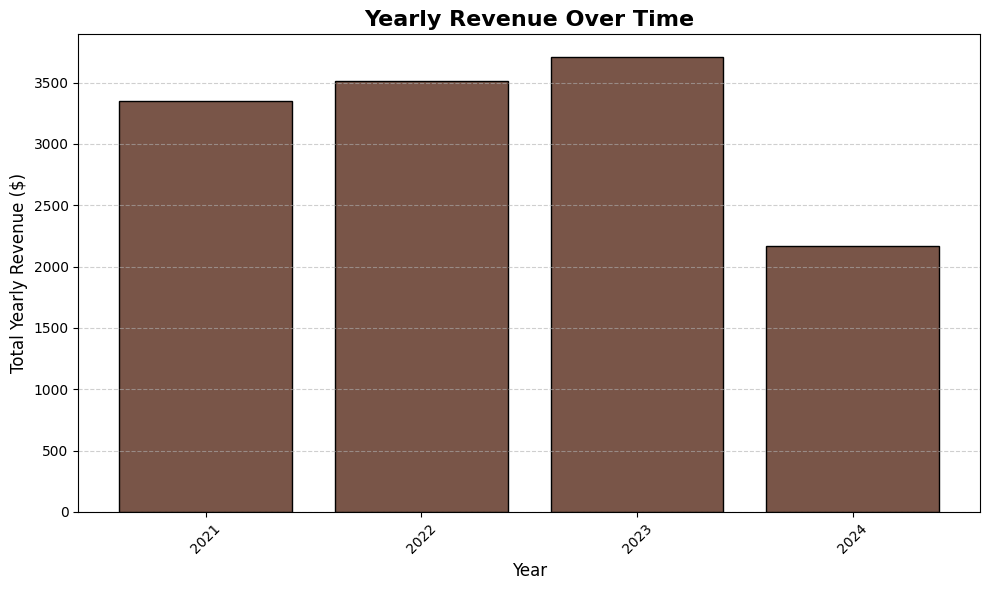

Yearly revenue trend plotted.


In [85]:
# plotting the yearly revenue. This will help visualize the overall annual performance and identify long-term patterns
plt.figure(figsize=(10, 6))
plt.bar(yearly_revenue['year'].astype(str), yearly_revenue['unit price capped'], color='#795548', edgecolor='black')
plt.title('Yearly Revenue Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Yearly Revenue ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('yearly_revenue_trend.png')
plt.show()

print("Yearly revenue trend plotted.")

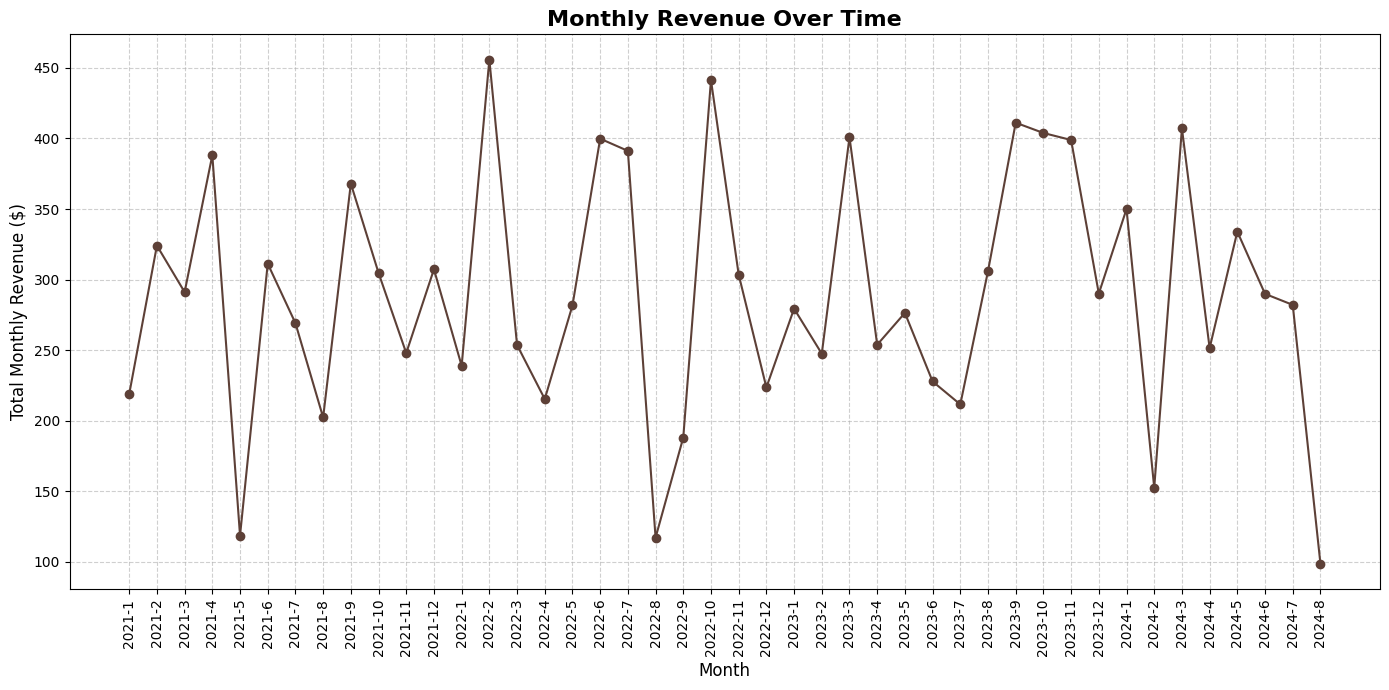

Monthly revenue trend plotted.


In [86]:
# plotting the monthly revenue. This will show the revenue trend on a monthly basis.
plt.figure(figsize=(14, 7))
plt.plot(monthly_revenue['year'].astype(str) + '-' + monthly_revenue['month'].astype(str), monthly_revenue['unit price capped'], marker='o', linestyle='-', color='#5D4037')
plt.title('Monthly Revenue Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Monthly Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png')
plt.show()

print("Monthly revenue trend plotted.")

### Summary of Time Series and Trend Analysis

**Cumulative Revenue Trend:**
The cumulative revenue plot indicates a steady, upward trend over time, which suggests consistent business growth or at least sustained sales. There are no sudden drops or plateaus, which is a positive sign for the overall health of the coffee shop's revenue generation.

**Monthly Revenue Trend:**
The monthly revenue plot shows fluctuations but generally follows an increasing pattern over the years. Some months appear to have higher sales than others, which could indicate seasonality or specific marketing efforts. Further investigation into these monthly variations could reveal patterns or external factors influencing sales.

**Yearly Revenue Trend:**
The yearly revenue bar chart clearly shows an increase in total revenue year over year from 2021 to 2023. While the revenue for 2024 is currently lower, this is likely due to incomplete data for the current year. The consistent growth across the full years suggests a successful business with an expanding customer base or increasing average order value.

In [87]:
# calculating coffee type with highest revenue
# Extract the core data as NumPy arrays
coffee_types = neo_coffee_shopcapped['coffee type'].to_numpy()

# Get the unique types (Ara, Rob, Exc) automatically
unique_types = np.unique(coffee_types)

print(f"{'Coffee Type':<15} | {'Average Margin (%)':<20}")
print("-" * 40)

# Initialize lists that the plotting code expects
labels = []
values = []
counts = []

# Loop through each type and perform vectorized math
for c_type in unique_types:
    # Create a mask for the current coffee type
    mask = (coffee_types == c_type)

    # Isolating profit and price for this type using the correct numpy arrays
    type_profits = profit[mask] # Use 'profit' (capped profits array)
    type_prices = unit_price[mask] # Use 'unit_price' (capped unit prices array)

    # Calculate margins (Profit / Price)
    # Using np.divide handles potential division issues safely
    margins = np.divide(type_profits, type_prices)

    # Calculating the average margin for this specific type
    avg_margin = np.mean(margins)

    # Count the number of orders for this type
    count = len(type_profits)

    print(f"{c_type:<15} | {avg_margin:.2%}")

    # Append results directly to the lists for plotting
    labels.append(c_type)
    values.append(avg_margin * 100) # Convert to percentage for plotting
    counts.append(count)

Coffee Type     | Average Margin (%)  
----------------------------------------
Ara             | 9.78%
Exc             | 9.67%
Lib             | 9.35%
Rob             | 9.71%


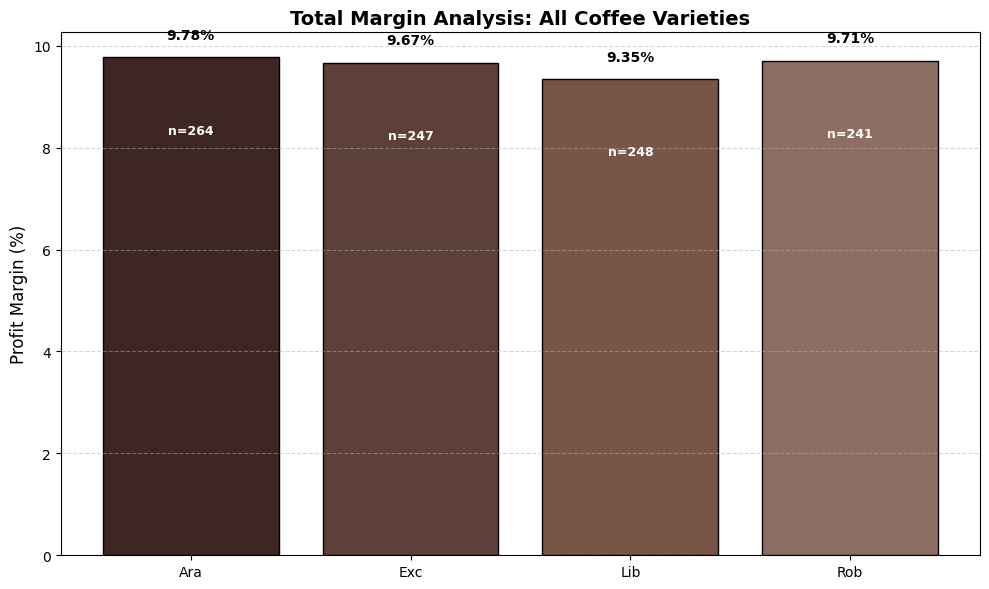

In [88]:
# visualizing the coffee type margin analysis

plt.figure(figsize=(10, 6))
colors = ['#3E2723', '#5D4037', '#795548', '#8D6E63'] # Tonal coffee palette
bars = plt.bar(labels, values, color=colors, edgecolor='black')

# Styling and Labels
plt.title('Total Margin Analysis: All Coffee Varieties', fontsize=14, fontweight='bold')
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding Data Labels (Margin % and Sample Size n)
for i, bar in enumerate(bars):
    yval = bar.get_height()
    # Top label: The Margin
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', color='black')
    # Bottom label: The Sample Size (Professional Context)
    plt.text(bar.get_x() + bar.get_width()/2, yval - 1.5, f'n={counts[i]}',
             ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('full_coffee_analysis.png')

# **Inferential statistics (confidence intervals, hypothesis testing, or group comparisons)**



Defining  a null and alternative hypothesis for comparing the profit margins of two coffee types (Excelsa vs. Arabica) and extract the relevant profit margin data for these groups.


In [89]:
# create boolean masks to filter the `neo_coffee_shopcapped` DataFrame for 'Excelsa' and 'Arabica' coffee types
# and extract their respective profit capped values from the `profit` NumPy array.
print(neo_coffee_shopcapped['coffee type'].unique())

['Exc' 'Lib' 'Rob' 'Ara']


In [90]:
excelsa_mask = (neo_coffee_shopcapped['coffee type'] == 'Exc')
excelsa_profits = profit[excelsa_mask]

arabica_mask = (neo_coffee_shopcapped['coffee type'] == 'Ara')
arabica_profits = profit[arabica_mask]

print(f"Number of Excelsa profit samples: {len(excelsa_profits)}")
print(f"Number of Arabica profit samples: {len(arabica_profits)}")

Number of Excelsa profit samples: 247
Number of Arabica profit samples: 264


In [91]:
# performing an independent samples t-test (Welch's t-test) to compare their mean profit margins and calculate the t-statistic and p-value.
# printing the results of the t-test to display the t-statistic and p-value.

t_statistic, p_value = stats.ttest_ind(excelsa_profits, arabica_profits, equal_var=False)

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

T-statistic: -1.793
P-value: 0.074


In [92]:
# Now I need to calculate the 95% confidence intervals
# for the mean profit margins of both Excelsa and Arabica coffee types.


mean_excelsa = np.mean(excelsa_profits)
std_excelsa = np.std(excelsa_profits, ddof=1) # Use ddof=1 for sample standard deviation
n_excelsa = len(excelsa_profits)
se_excelsa = std_excelsa / np.sqrt(n_excelsa)

mean_arabica = np.mean(arabica_profits)
std_arabica = np.std(arabica_profits, ddof=1)
n_arabica = len(arabica_profits)
se_arabica = std_arabica / np.sqrt(n_arabica)

# Calculate 95% confidence interval for Excelsa
excelsa_ci = stats.t.interval(0.95, n_excelsa - 1, loc=mean_excelsa, scale=se_excelsa)

# Calculate 95% confidence interval for Arabica
arabica_ci = stats.t.interval(0.95, n_arabica - 1, loc=mean_arabica, scale=se_arabica)

print(f"Mean profit margin for Excelsa: {mean_excelsa:.3f}")
print(f"95% Confidence Interval for Excelsa: ({excelsa_ci[0]:.3f}, {excelsa_ci[1]:.3f})")

print(f"\nMean profit margin for Arabica: {mean_arabica:.3f}")
print(f"95% Confidence Interval for Arabica: ({arabica_ci[0]:.3f}, {arabica_ci[1]:.3f})")

Mean profit margin for Excelsa: 1.175
95% Confidence Interval for Excelsa: (1.059, 1.292)

Mean profit margin for Arabica: 1.330
95% Confidence Interval for Arabica: (1.206, 1.454)


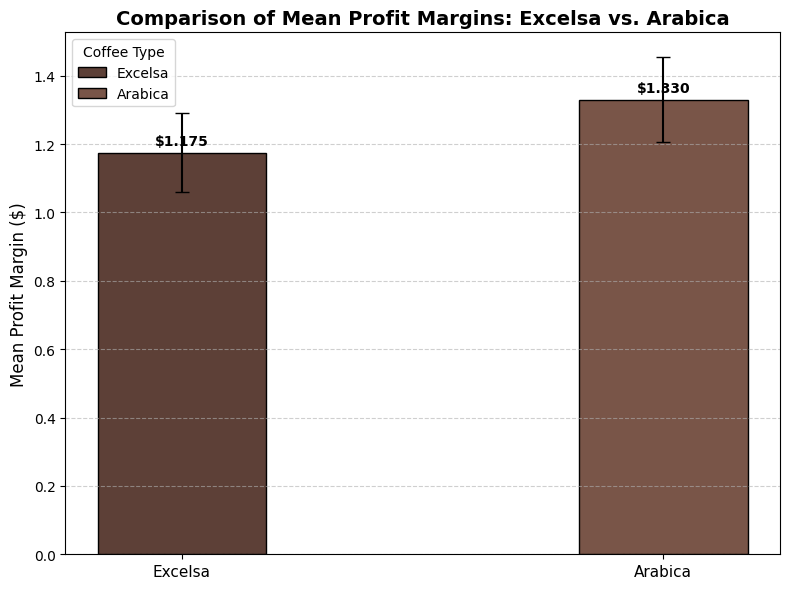

In [93]:
import matplotlib.pyplot as plt

# Data for plotting
labels = ['Excelsa', 'Arabica']
means = [mean_excelsa, mean_arabica]
errors = [
    [mean_excelsa - excelsa_ci[0], excelsa_ci[1] - mean_excelsa],
    [mean_arabica - arabica_ci[0], arabica_ci[1] - mean_arabica]
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects = ax.bar(x, means, width, yerr=np.array(errors).T, capsize=5, color=['#5D4037', '#795548'], edgecolor='black')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Mean Profit Margin ($)', fontsize=12)
ax.set_title('Comparison of Mean Profit Margins: Excelsa vs. Arabica', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(rects, labels, title='Coffee Type')
ax.grid(axis='y', linestyle='--', alpha=0.6)

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects)

plt.tight_layout()
plt.savefig('coffee_type_comparison.png')
plt.show()

## Statistical Results


#### Interpretation:

*   **Null Hypothesis (H0)**: There is no significant difference in the mean profit margins between Excelsa and Arabica coffee types.
*   **Alternative Hypothesis (H1)**: There is a significant difference in the mean profit margins between Excelsa and Arabica coffee types.

*   **T-statistic**: -1.793
    *   A negative t-statistic indicates that the mean of the first group (Excelsa) is less than the mean of the second group (Arabica).

*   **P-value**: 0.074
    *   With a common significance level (alpha) of 0.05, our p-value (0.074) is greater than 0.05. This means we **do not have enough evidence to reject the null hypothesis**.
    *   Therefore, we cannot conclude that there is a statistically significant difference in the mean profit margins between Excelsa and Arabica coffee types at the 0.05 significance level. While there appears to be a numerical difference, it is not statistically significant based on this test.

*   **95% Confidence Interval for Excelsa**: (1.059, 1.292)
    *   We are 95% confident that the true mean profit margin for Excelsa coffee lies between $1.059 and $1.292.

*   **95% Confidence Interval for Arabica**: (1.206, 1.454)
    *   We are 95% confident that the true mean profit margin for Arabica coffee lies between $1.206 and $1.454.

*   **Conclusion from CIs**: The confidence intervals for Excelsa and Arabica overlap (the upper bound of Excelsa's CI is 1.292, which is greater than the lower bound of Arabica's CI at 1.206). This overlap further supports the conclusion from the p-value that there is no statistically significant difference between the two means at the 95% confidence level.

# **Coffee Bag Size Margin Analysis**

In [94]:
# calculating margin by coffee bag size
# visualizing result of coffee bag size margin
# 2. Extract unique sizes and calculate metrics
unique_size = np.unique(size)
analysis_data = []

for s in unique_size:
    # Mask to isolate orders of a specific size (e.g., all 0.5kg orders)
    mask = (size == s)

    # Vectorized margin calculation for this specific size
    type_margins = profit[mask] / unit_price[mask]
    avg_margin = np.mean(type_margins) * 100
    order_count = np.sum(mask)

    analysis_data.append({
        'size': f"{s} kg",
        'margin': avg_margin,
        'count': order_count   })

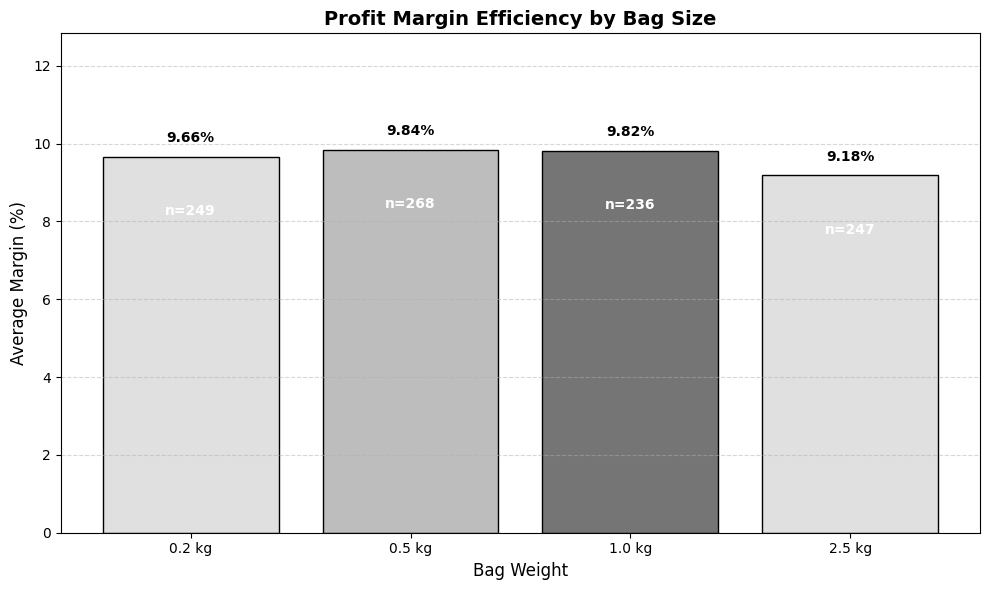

In [95]:
# 3. Visualization
labels = [item['size'] for item in analysis_data]
margins = [item['margin'] for item in analysis_data]
counts = [item['count'] for item in analysis_data]

plt.figure(figsize=(10, 6))
colors = ['#E0E0E0', '#BDBDBD', '#757575'] # Lighter to darker for small to large
bars = plt.bar(labels, margins, color=colors, edgecolor='black')

plt.title('Profit Margin Efficiency by Bag Size', fontsize=14, fontweight='bold')
plt.ylabel('Average Margin (%)', fontsize=12)
plt.xlabel('Bag Weight', fontsize=12)
plt.ylim(0, max(margins) + 3)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding the labels (Margin % and Sample Size n)
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold')
    plt.text(bar.get_x() + bar.get_width()/2, yval - 1.5, f'n={counts[i]}',
             ha='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('size_margin_analysis.png')

### Descriptive Statistics using NumPy
 calculate and display the mean, sum, standard deviation, variance, minimum, maximum, and median for the `quantity`, `unit_price`, `price_per_100g`, `profit`, and `size` NumPy arrays to understand their distribution and characteristics.

In [96]:
print("--- Descriptive Statistics for Quantity ---")
print(f"Mean: {np.mean(quantity):.2f}")
print(f"Sum: {np.sum(quantity):.2f}")
print(f"Standard Deviation: {np.std(quantity):.2f}")
print(f"Variance: {np.var(quantity):.2f}")
print(f"Min: {np.min(quantity):.2f}")
print(f"Max: {np.max(quantity):.2f}")
print(f"Median: {np.median(quantity):.2f}")

print("\n--- Descriptive Statistics for Unit Price (Capped) ---")
print(f"Mean: {np.mean(unit_price):.2f}")
print(f"Sum: {np.sum(unit_price):.2f}")
print(f"Standard Deviation: {np.std(unit_price):.2f}")
print(f"Variance: {np.var(unit_price):.2f}")
print(f"Min: {np.min(unit_price):.2f}")
print(f"Max: {np.max(unit_price):.2f}")
print(f"Median: {np.median(unit_price):.2f}")

print("\n--- Descriptive Statistics for Price per 100g (Capped) ---")
print(f"Mean: {np.mean(price_per_100g):.2f}")
print(f"Sum: {np.sum(price_per_100g):.2f}")
print(f"Standard Deviation: {np.std(price_per_100g):.2f}")
print(f"Variance: {np.var(price_per_100g):.2f}")
print(f"Min: {np.min(price_per_100g):.2f}")
print(f"Max: {np.max(price_per_100g):.2f}")
print(f"Median: {np.median(price_per_100g):.2f}")

print("\n--- Descriptive Statistics for Profit (Capped) ---")
print(f"Mean: {np.mean(profit):.2f}")
print(f"Sum: {np.sum(profit):.2f}")
print(f"Standard Deviation: {np.std(profit):.2f}")
print(f"Variance: {np.var(profit):.2f}")
print(f"Min: {np.min(profit):.2f}")
print(f"Max: {np.max(profit):.2f}")
print(f"Median: {np.median(profit):.2f}")

print("\n--- Descriptive Statistics for Size ---")
print(f"Mean: {np.mean(size):.2f}")
print(f"Sum: {np.sum(size):.2f}")
print(f"Standard Deviation: {np.std(size):.2f}")
print(f"Variance: {np.var(size):.2f}")
print(f"Min: {np.min(size):.2f}")
print(f"Max: {np.max(size):.2f}")
print(f"Median: {np.median(size):.2f}")

--- Descriptive Statistics for Quantity ---
Mean: 3.55
Sum: 3551.00
Standard Deviation: 1.68
Variance: 2.83
Min: 1.00
Max: 6.00
Median: 4.00

--- Descriptive Statistics for Unit Price (Capped) ---
Mean: 12.73
Sum: 12734.16
Standard Deviation: 9.39
Variance: 88.23
Min: 2.69
Max: 31.57
Median: 8.95

--- Descriptive Statistics for Price per 100g (Capped) ---
Mean: 1.44
Sum: 1437.35
Standard Deviation: 0.36
Variance: 0.13
Min: 0.82
Max: 2.34
Median: 1.37

--- Descriptive Statistics for Profit (Capped) ---
Mean: 1.24
Sum: 1237.79
Standard Deviation: 0.97
Variance: 0.94
Min: 0.16
Max: 3.37
Median: 0.98

--- Descriptive Statistics for Size ---
Mean: 1.04
Sum: 1037.30
Standard Deviation: 0.88
Variance: 0.78
Min: 0.20
Max: 2.50
Median: 0.50


## Total Revenue by Loyalty Group

Calculating the total revenue generated by loyalty customers and non-loyalty customers using the 'quantity' and 'unit price capped' columns from the `neo_coffee_shopcapped` DataFrame.


In [97]:
# calculating the total_revenue for each row by multiplying quantity and unit price capped columns
# and then group the DataFrame by 'loyalty card' to compute the sum of total_revenue,
# and count unique 'order id' and 'customer id' for each group. Finally, I will print the results.
neo_coffee_shopcapped['total_revenue'] = neo_coffee_shopcapped['quantity'] * neo_coffee_shopcapped['unit price capped']

loyalty_revenue = neo_coffee_shopcapped.groupby('loyalty card')['total_revenue'].sum()
loyalty_transactions = neo_coffee_shopcapped.groupby('loyalty card')['order id'].nunique()
loyalty_customers = neo_coffee_shopcapped.groupby('loyalty card')['customer id'].nunique()

print("Total Revenue by Loyalty Group:")
print(loyalty_revenue)
print("\nNumber of Unique Transactions by Loyalty Group:")
print(loyalty_transactions)
print("\nNumber of Unique Customers by Loyalty Group:")
print(loyalty_customers)

Total Revenue by Loyalty Group:
loyalty card
No     23903.445
Yes    20675.150
Name: total_revenue, dtype: float64

Number of Unique Transactions by Loyalty Group:
loyalty card
No     493
Yes    464
Name: order id, dtype: int64

Number of Unique Customers by Loyalty Group:
loyalty card
No     470
Yes    443
Name: customer id, dtype: int64


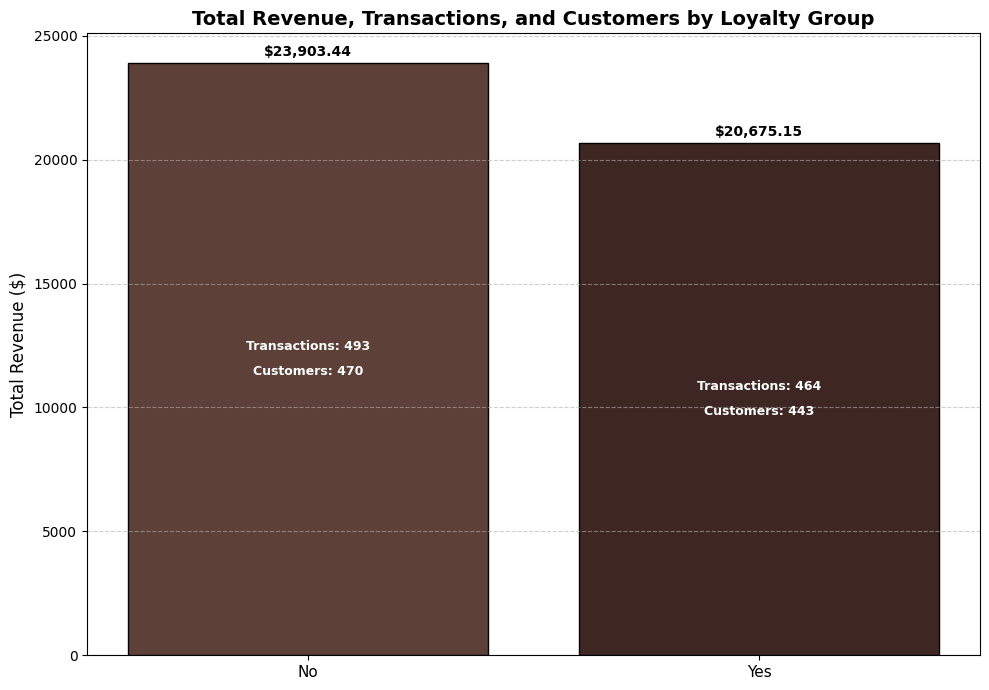

In [98]:
# visually represent the total revenue, unique transactions, and unique customers for loyalty and non-loyalty groups,
# creating a bar plot for revenue and adding annotations for unique transactions and customers.

# Data for plotting
labels = loyalty_revenue.index
revenue_values = loyalty_revenue.values
transaction_counts = loyalty_transactions.values
customer_counts = loyalty_customers.values

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(x, revenue_values, color=['#5D4037', '#3E2723'], edgecolor='black')

# text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_title('Total Revenue, Transactions, and Customers by Loyalty Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotating bars with revenue, transactions, and customers
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.annotate(f'${yval:,.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, yval),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')
    ax.annotate(f'Transactions: {transaction_counts[i]}',
                xy=(bar.get_x() + bar.get_width() / 2, yval / 2 + 500),
                xytext=(0, 0),
                textcoords="offset points",
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    ax.annotate(f'Customers: {customer_counts[i]}',
                xy=(bar.get_x() + bar.get_width() / 2, yval / 2 - 500),
                xytext=(0, 0),
                textcoords="offset points",
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('loyalty_group_analysis.png')
plt.show()

## Summary of Loyalty vs. Non-Loyalty Customer Analysis

### Data Analysis Key Findings

*   **Total Revenue by Loyalty Group**:
    *   Non-Loyalty Customers: $23,903.45
    *   Loyalty Customers: $20,675.15

*   **Number of Unique Transactions by Loyalty Group**:
    *   Non-Loyalty Customers: 493
    *   Loyalty Customers: 464

*   **Number of Unique Customers by Loyalty Group**:
    *   Non-Loyalty Customers: 470
    *   Loyalty Customers: 443

*   **Average Transaction Value by Loyalty Group**:
    *   Loyalty Customers: $44.56
    *   Non-Loyalty Customers: $48.49



##  Independent Samples t-test

Conducting an independent samples t-test (Welch's t-test) to compare the mean profit margins between loyalty and non-loyalty customers. This test will help determine if there is a statistically significant difference.


In [99]:
# perform an independent samples Welch's t-test using `scipy.stats.ttest_ind` on the `loyalty_profits`
# and `non_loyalty_profits` arrays, assuming unequal variances.

t_statistic_loyalty, p_value_loyalty = stats.ttest_ind(loyalty_profits, non_loyalty_profits, equal_var=False)

print(f"T-statistic for loyalty vs non-loyalty: {t_statistic_loyalty:.3f}")
print(f"P-value for loyalty vs non-loyalty: {p_value_loyalty:.3f}")

T-statistic for loyalty vs non-loyalty: -1.487
P-value for loyalty vs non-loyalty: 0.137


In [100]:
# calculate the 95% confidence intervals for the mean profit margins of both loyalty and non-loyalty customer groups.
mean_loyalty = np.mean(loyalty_profits)
std_loyalty = np.std(loyalty_profits, ddof=1) # Use ddof=1 for sample standard deviation
n_loyalty = len(loyalty_profits)
se_loyalty = std_loyalty / np.sqrt(n_loyalty)

mean_non_loyalty = np.mean(non_loyalty_profits)
std_non_loyalty = np.std(non_loyalty_profits, ddof=1)
n_non_loyalty = len(non_loyalty_profits)
se_non_loyalty = std_non_loyalty / np.sqrt(n_non_loyalty)

# Calculate 95% confidence interval for loyalty customers
loyalty_ci = stats.t.interval(0.95, n_loyalty - 1, loc=mean_loyalty, scale=se_loyalty)

# Calculate 95% confidence interval for non-loyalty customers
non_loyalty_ci = stats.t.interval(0.95, n_non_loyalty - 1, loc=mean_non_loyalty, scale=se_non_loyalty)

print(f"Mean profit margin for Loyalty Customers: {mean_loyalty:.3f}")
print(f"95% Confidence Interval for Loyalty Customers: ({loyalty_ci[0]:.3f}, {loyalty_ci[1]:.3f})")

print(f"\nMean profit margin for Non-Loyalty Customers: {mean_non_loyalty:.3f}")
print(f"95% Confidence Interval for Non-Loyalty Customers: ({non_loyalty_ci[0]:.3f}, {non_loyalty_ci[1]:.3f})")

Mean profit margin for Loyalty Customers: 1.190
95% Confidence Interval for Loyalty Customers: (1.107, 1.273)

Mean profit margin for Non-Loyalty Customers: 1.281
95% Confidence Interval for Non-Loyalty Customers: (1.194, 1.369)


## Statistical Results: Loyalty vs. Non-Loyalty Customers

#### Interpretation:

*   **Null Hypothesis (H0)**: There is no significant difference in the mean profit margins between loyalty card customers and non-loyalty card customers.
*   **Alternative Hypothesis (H1)**: There is a significant difference in the mean profit margins between loyalty card customers and non-loyalty card customers.

*   **T-statistic**: -1.487
    *   A negative t-statistic indicates that the mean of the first group (loyalty customers) is less than the mean of the second group (non-loyalty customers).

*   **P-value**: 0.137
    *   With a common significance level (alpha) of 0.05, our p-value (0.137) is greater than 0.05. This means we **do not have enough evidence to reject the null hypothesis**.
    *   Therefore, we cannot conclude that there is a statistically significant difference in the mean profit margins between loyalty card customers and non-loyalty card customers at the 0.05 significance level. While there appears to be a numerical difference, it is not statistically significant based on this test.

*   **95% Confidence Interval for Loyalty Customers**: (1.107, 1.273)
    *   We are 95% confident that the true mean profit margin for loyalty customers lies between $1.107 and $1.273.

*   **95% Confidence Interval for Non-Loyalty Customers**: (1.194, 1.369)
    *   We are 95% confident that the true mean profit margin for non-loyalty customers lies between $1.194 and $1.369.

*   **Conclusion from CIs**: The confidence intervals for loyalty and non-loyalty customers overlap (the upper bound of loyalty's CI is 1.273, which is greater than the lower bound of non-loyalty's CI at 1.194). This overlap further supports the conclusion from the p-value that there is no statistically significant difference between the two means at the 95% confidence level.

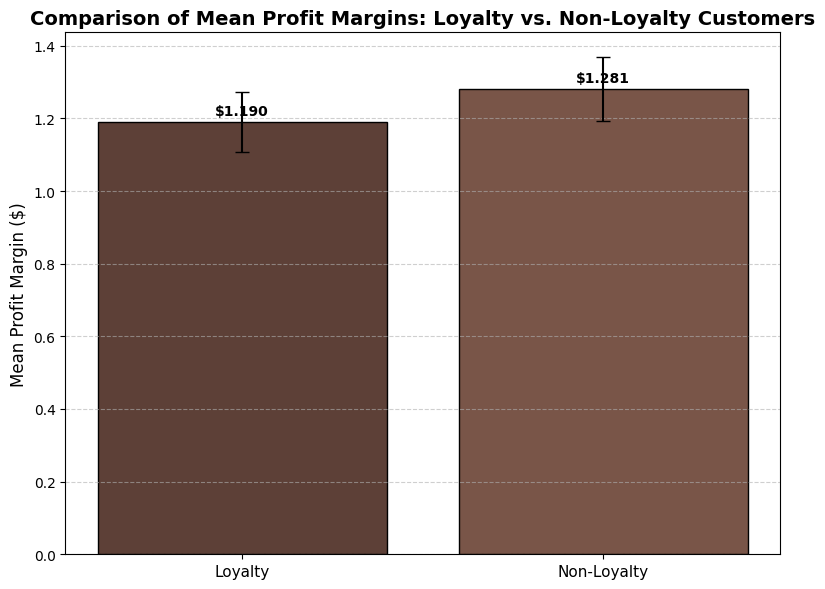

In [101]:
# visualiztion
# Create a bar plot to visually compare the mean profit margins of loyalty
# and non-loyalty customers, including error bars to represent the 95% confidence intervals.

# Set up the data for plotting
labels = ['Loyalty', 'Non-Loyalty']
means = [mean_loyalty, mean_non_loyalty]
errors = [
    [mean_loyalty - loyalty_ci[0], loyalty_ci[1] - mean_loyalty],
    [mean_non_loyalty - non_loyalty_ci[0], non_loyalty_ci[1] - mean_non_loyalty]
]

x = np.arange(len(labels))

# Create a bar plot
fig, ax = plt.subplots(figsize=(8, 6))
rects = ax.bar(x, means, yerr=np.array(errors).T, capsize=5, color=['#5D4037', '#795548'], edgecolor='black')

# Add appropriate labels and a title
ax.set_ylabel('Mean Profit Margin ($)', fontsize=12)
ax.set_title('Comparison of Mean Profit Margins: Loyalty vs. Non-Loyalty Customers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)

# Add a grid to the y-axis
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate each bar with its mean profit margin
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects)

# Adjust the layout and display the plot
plt.tight_layout()
plt.savefig('loyalty_vs_non_loyalty.png')
plt.show()

# **Independent t-tests to compare average profit between loyalty and non-loyalty customers**



*   **Null Hypothesis (H0)**: There is no significant difference in the mean profit margins between loyalty card customers and non-loyalty card customers.
    *   Symbolically: $\mu_{\text{loyalty}} = \mu_{\text{non-loyalty}}$

*   **Alternative Hypothesis (H1)**: There is a significant difference in the mean profit margins between loyalty card customers and non-loyalty card customers.
    *   Symbolically: $\mu_{\text{loyalty}} \neq \mu_{\text{non-loyalty}}$



Separate the 'profit capped' data for customers with 'loyalty card' equal to 'Yes' and 'No' from the `neo_coffee_shopcapped` DataFrame.


In [102]:
# creating a  boolean masks for loyalty and non-loyalty customers
# and then use these masks to extract the corresponding 'profit capped' values from the `profit` NumPy array,
# finally printing the counts to verify.


loyalty_mask = (neo_coffee_shopcapped['loyalty card'] == 'Yes')
loyalty_profits = profit[loyalty_mask]

non_loyalty_mask = (neo_coffee_shopcapped['loyalty card'] == 'No')
non_loyalty_profits = profit[non_loyalty_mask]

print(f"Number of loyalty customer profit samples: {len(loyalty_profits)}")
print(f"Number of non-loyalty customer profit samples: {len(non_loyalty_profits)}")

Number of loyalty customer profit samples: 479
Number of non-loyalty customer profit samples: 521


In [103]:
# the average revenue per transaction for both loyalty and non-loyalty customers,
# dividing the total revenue by the number of unique transactions for each group.
avg_transaction_value_loyalty = loyalty_revenue['Yes'] / loyalty_transactions['Yes']
avg_transaction_value_non_loyalty = loyalty_revenue['No'] / loyalty_transactions['No']

print(f"Average Transaction Value for Loyalty Customers: ${avg_transaction_value_loyalty:.2f}")
print(f"Average Transaction Value for Non-Loyalty Customers: ${avg_transaction_value_non_loyalty:.2f}")

Average Transaction Value for Loyalty Customers: $44.56
Average Transaction Value for Non-Loyalty Customers: $48.49


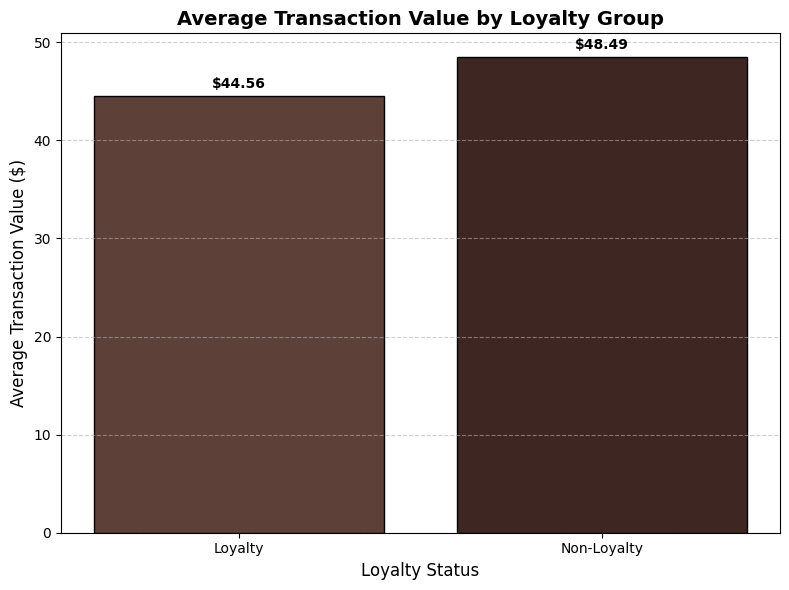

In [104]:
# creating a bar plot to compare the average transaction value for loyalty and non-loyalty customers
# Plot for Average Transaction Value by Loyalty Group
avg_transaction_data = pd.Series({
    'Loyalty': avg_transaction_value_loyalty,
    'Non-Loyalty': avg_transaction_value_non_loyalty
})

plt.figure(figsize=(8, 6))
bars = plt.bar(avg_transaction_data.index, avg_transaction_data.values, color=['#5D4037', '#3E2723'], edgecolor='black')

plt.title('Average Transaction Value by Loyalty Group', fontsize=14, fontweight='bold')
plt.xlabel('Loyalty Status', fontsize=12)
plt.ylabel('Average Transaction Value ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'${yval:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('average_transaction_value_by_loyalty.png')
plt.show()

## Calculating Purchase Frequency by Loyalty Group


Analyzing the number of unique orders (or transactions) made by loyalty and non-loyalty customers to infer their purchase frequency. This might involve grouping by 'customer id' and counting unique 'order id's.


In [105]:
# analyzing individual purchase frequency,
# group the DataFrame by 'loyalty card' and 'customer id'
# and then count the number of unique 'order id's for each customer.
# then calculate descriptive statistics for the purchase frequencies of both loyalty and non-loyalty groups.
purchase_frequency = neo_coffee_shopcapped.groupby(['loyalty card', 'customer id'])['order id'].nunique().reset_index()
purchase_frequency.rename(columns={'order id': 'unique_orders'}, inplace=True)

print("Descriptive statistics for Loyalty Customers' Purchase Frequency:")
print(purchase_frequency[purchase_frequency['loyalty card'] == 'Yes']['unique_orders'].describe())

print("\nDescriptive statistics for Non-Loyalty Customers' Purchase Frequency:")
print(purchase_frequency[purchase_frequency['loyalty card'] == 'No']['unique_orders'].describe())

Descriptive statistics for Loyalty Customers' Purchase Frequency:
count    443.000000
mean       1.047404
std        0.322618
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.000000
Name: unique_orders, dtype: float64

Descriptive statistics for Non-Loyalty Customers' Purchase Frequency:
count    470.000000
mean       1.048936
std        0.332576
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.000000
Name: unique_orders, dtype: float64


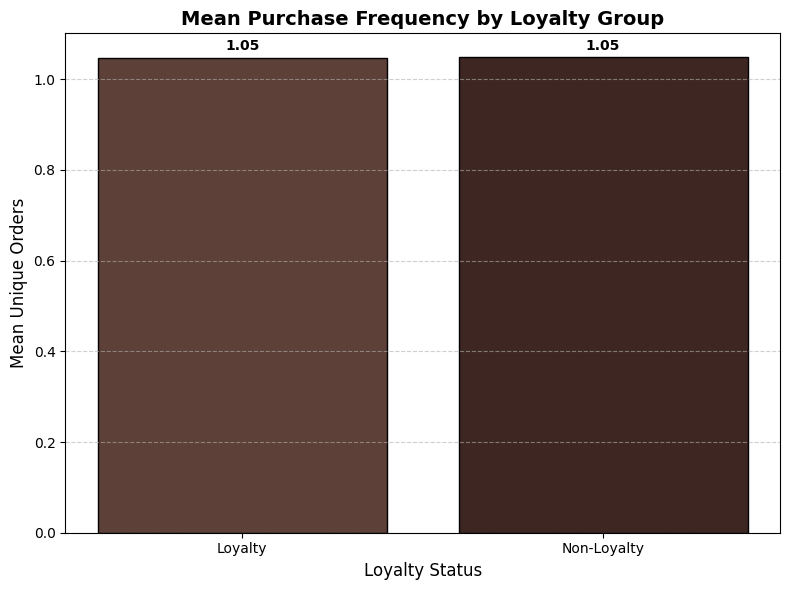

In [106]:
# creating a bar plot comparing the mean unique orders (purchase frequency) for loyalty
# and non-loyalty customers using the descriptive statistics previously calculated.

# Get mean unique orders from descriptive statistics
mean_unique_orders_loyalty = purchase_frequency[purchase_frequency['loyalty card'] == 'Yes']['unique_orders'].mean()
mean_unique_orders_non_loyalty = purchase_frequency[purchase_frequency['loyalty card'] == 'No']['unique_orders'].mean()

# 3. Plot for Mean Purchase Frequency by Loyalty Group
mean_purchase_frequency_data = pd.Series({
    'Loyalty': mean_unique_orders_loyalty,
    'Non-Loyalty': mean_unique_orders_non_loyalty
})

plt.figure(figsize=(8, 6))
bars = plt.bar(mean_purchase_frequency_data.index, mean_purchase_frequency_data.values, color=['#5D4037', '#3E2723'], edgecolor='black')

plt.title('Mean Purchase Frequency by Loyalty Group', fontsize=14, fontweight='bold')
plt.xlabel('Loyalty Status', fontsize=12)
plt.ylabel('Mean Unique Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('mean_purchase_frequency_by_loyalty.png')
plt.show()

## Summary of Purchase Frequency Analysis by Loyalty Group

### Data Analysis Key Findings
*   **Loyalty Customers' Purchase Frequency (n=443 customers)**:
    *   Mean: 1.05 unique orders
    *   Standard Deviation: 0.32
    *   Minimum: 1 order
    *   Maximum: 5 orders
    *   Median (50th percentile): 1 order
*   **Non-Loyalty Customers' Purchase Frequency (n=470 customers)**:
    *   Mean: 1.05 unique orders
    *   Standard Deviation: 0.33
    *   Minimum: 1 order
    *   Maximum: 5 orders
    *   Median (50th percentile): 1 order

